In [ ]:
!pip install numpy tensorflow scikit-learn matplotlib

In [ ]:
pip install scikit-image

NEURO-FUZZY HYBRID DIGIT RECOGNITION SYSTEM

[STEP 1] Loading MNIST data...
Training: 51000, Validation: 9000, Test: 10000

[STEP 2] Building Neuro-Fuzzy Hybrid Model...

Model Architecture:


Model: "NeuroFuzzy_Digit_Recognizer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 28, 28)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 784)       │          0 │ input_layer_11[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_1 (Dense)   │ (None, 128)       │    100,480 │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 128)       │          0 │ feature_1[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_2 (Dense)   │ (None, 64)        │      8,256 │ dropout_23[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 64)        │          0 │ feature_2[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuzzy_input (Dense) │ (None, 32)        │      2,080 │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuzzy_rules         │ (None, 20)        │      1,280 │ fuzzy_input[0][0] │
│ (FuzzyLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fuzzy_inference     │ (None, 10)        │        200 │ fuzzy_rules[0][0] │
│ (FuzzyInferenceLay… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ neural_output       │ (None, 10)        │        650 │ dropout_24[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_combination  │ (None, 10)        │          0 │ fuzzy_inference[… │
│ (Add)               │                   │            │ neural_output[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ final_output        │ (None, 10)        │          0 │ hybrid_combinati… │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 112,946 (441.20 KB)

 Trainable params: 112,946 (441.20 KB)

 Non-trainable params: 0 (0.00 B)


[STEP 3] Training Neuro-Fuzzy Model...
Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.6995 - loss: 0.9379 - val_accuracy: 0.9362 - val_loss: 0.2096 - learning_rate: 0.0010
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9211 - loss: 0.2745 - val_accuracy: 0.9550 - val_loss: 0.1477 - learning_rate: 0.0010
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9398 - loss: 0.2052 - val_accuracy: 0.9630 - val_loss: 0.1235 - learning_rate: 0.0010
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9505 - loss: 0.1724 - val_accuracy: 0.9669 - val_loss: 0.1042 - learning_rate: 0.0010
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9556 - loss: 0.1505 - val_accuracy: 0.9720 - val_loss: 0.0973 - learning_rate: 0.0010
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9619 - loss: 0.1305 - val_accuracy: 0.9736 - val_loss: 0.0897 - learning_rate: 0.0010
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s

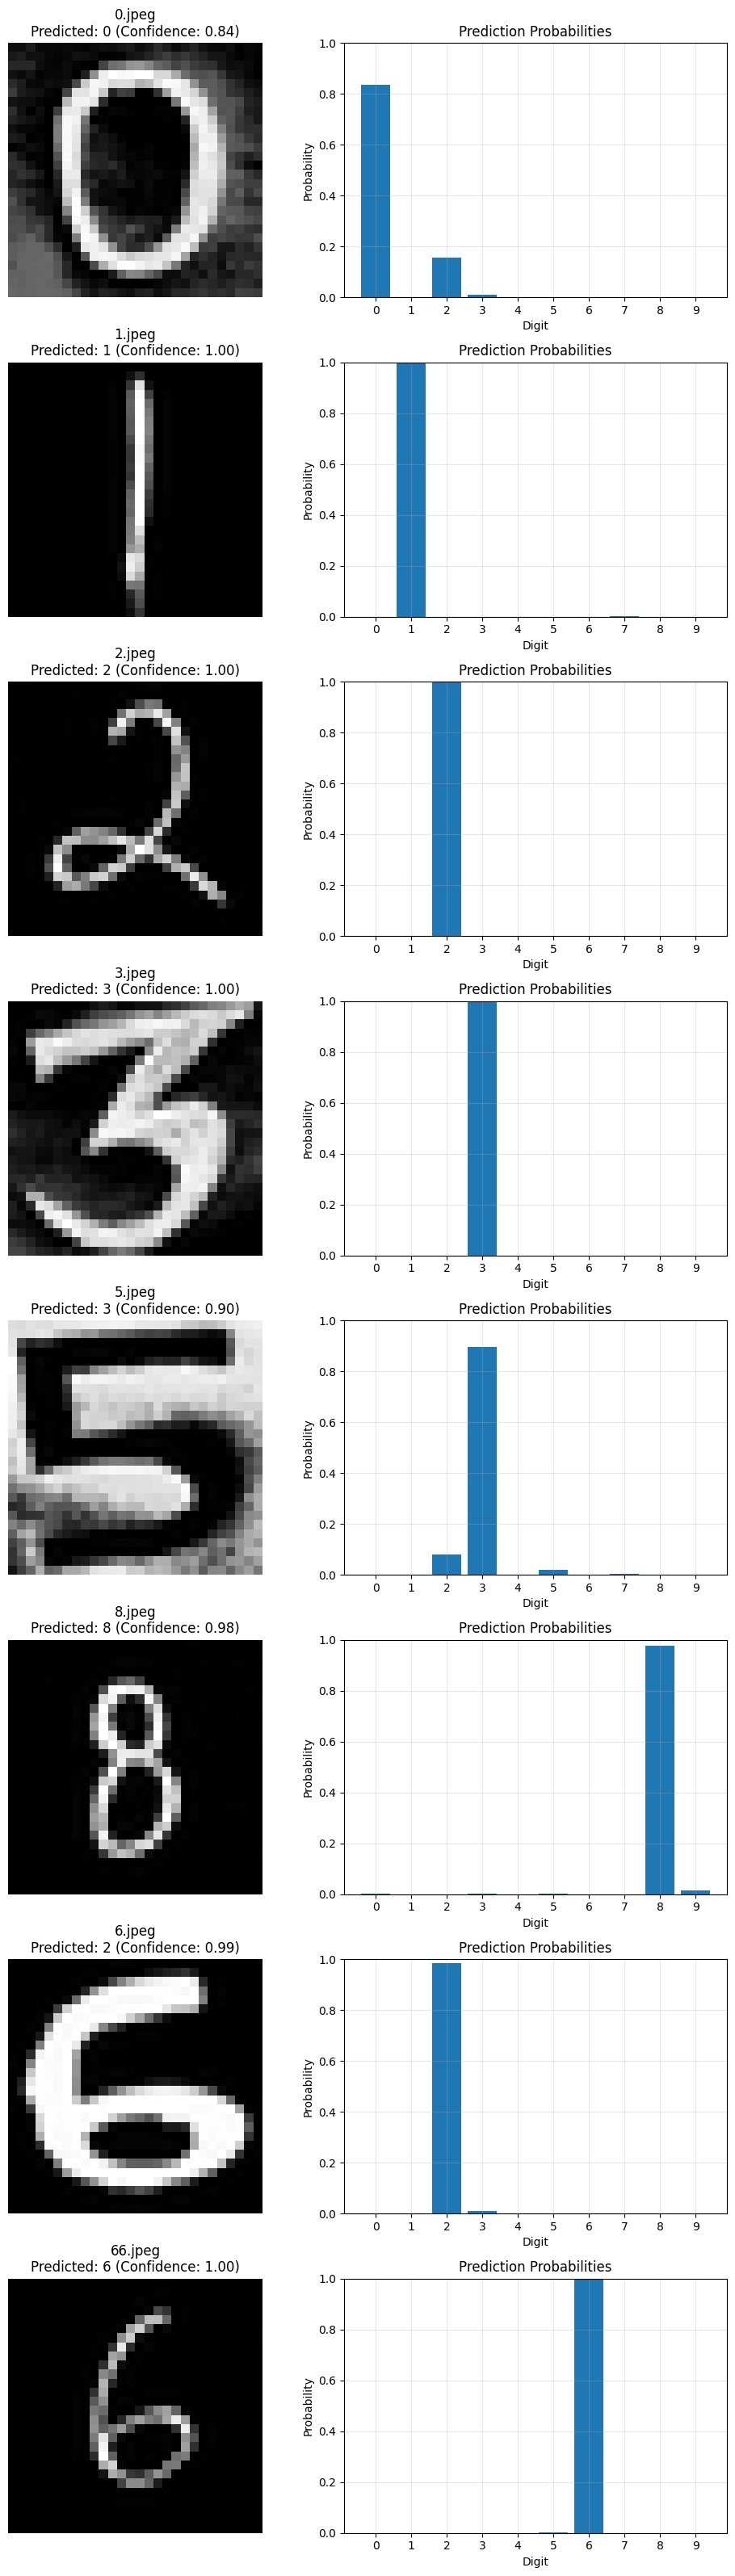

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import os

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("NEURO-FUZZY HYBRID DIGIT RECOGNITION SYSTEM")
print("="*70)

# ============================================================================
# FUZZY MEMBERSHIP FUNCTIONS
# ============================================================================

class FuzzyLayer(keras.layers.Layer):
    """
    Custom Fuzzy Layer that applies fuzzy membership functions
    to neural network outputs for hybrid neuro-fuzzy processing
    """
    def __init__(self, num_rules=5, **kwargs):
        super(FuzzyLayer, self).__init__(**kwargs)
        self.num_rules = num_rules

    def build(self, input_shape):
        # Learnable parameters for Gaussian membership functions
        # Centers and widths for each rule
        self.centers = self.add_weight(
            name='centers',
            shape=(input_shape[-1], self.num_rules),
            initializer=keras.initializers.RandomUniform(0.2, 0.8),
            trainable=True
        )
        self.widths = self.add_weight(
            name='widths',
            shape=(input_shape[-1], self.num_rules),
            initializer=keras.initializers.Constant(0.3),
            trainable=True
        )
        super(FuzzyLayer, self).build(input_shape)

    def call(self, inputs):
        # Apply Gaussian membership functions
        # Shape: (batch, features) -> (batch, features, rules)
        inputs_expanded = tf.expand_dims(inputs, -1)

        # Gaussian membership: exp(-((x - c)^2 / (2 * sigma^2)))
        memberships = tf.exp(
            -tf.square(inputs_expanded - self.centers) /
            (2 * tf.square(tf.abs(self.widths) + 1e-6))
        )

        # Aggregate across features (T-norm: product)
        # Shape: (batch, rules)
        rule_activations = tf.reduce_prod(memberships, axis=1)

        return rule_activations

    def get_config(self):
        config = super(FuzzyLayer, self).get_config()
        config.update({'num_rules': self.num_rules})
        return config


class FuzzyInferenceLayer(keras.layers.Layer):
    """
    Fuzzy Inference Layer that combines rule activations
    with consequent parameters (Takagi-Sugeno style)
    """
    def __init__(self, num_classes, **kwargs):
        super(FuzzyInferenceLayer, self).__init__(**kwargs)
        self.num_classes = num_classes

    def build(self, input_shape):
        num_rules = input_shape[-1]
        # Consequent parameters for each rule and class
        self.consequents = self.add_weight(
            name='consequents',
            shape=(num_rules, self.num_classes),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True
        )
        super(FuzzyInferenceLayer, self).build(input_shape)

    def call(self, inputs):
        # Weighted sum of consequents by rule activations
        # Normalize rule activations
        normalized = inputs / (tf.reduce_sum(inputs, axis=-1, keepdims=True) + 1e-6)

        # Compute output: sum(activation * consequent)
        output = tf.matmul(normalized, self.consequents)

        return output

    def get_config(self):
        config = super(FuzzyInferenceLayer, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ============================================================================
# LOAD AND PREPROCESS DATA
# ============================================================================

print("\n[STEP 1] Loading MNIST data...")
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

print(f"Training: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# ============================================================================
# BUILD NEURO-FUZZY MODEL
# ============================================================================

print("\n[STEP 2] Building Neuro-Fuzzy Hybrid Model...")

# Input layer
inputs = keras.Input(shape=(28, 28))
x = keras.layers.Flatten()(inputs)

# Neural feature extraction layers
x = keras.layers.Dense(128, activation='relu', name='feature_1')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu', name='feature_2')(x)
x = keras.layers.Dropout(0.3)(x)

# Fuzzy processing layer
fuzzy_features = keras.layers.Dense(32, activation='sigmoid', name='fuzzy_input')(x)

# Apply fuzzy membership functions
fuzzy_rules = FuzzyLayer(num_rules=20, name='fuzzy_rules')(fuzzy_features)

# Fuzzy inference
fuzzy_output = FuzzyInferenceLayer(num_classes=10, name='fuzzy_inference')(fuzzy_rules)

# Neural classification path (parallel)
neural_output = keras.layers.Dense(10, activation='linear', name='neural_output')(x)

# Combine both paths (hybrid)
combined = keras.layers.Add(name='hybrid_combination')([fuzzy_output, neural_output])
outputs = keras.layers.Activation('softmax', name='final_output')(combined)

# Build model
model = keras.Model(inputs=inputs, outputs=outputs, name='NeuroFuzzy_Digit_Recognizer')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
model.summary()

# ============================================================================
# TRAIN MODEL
# ============================================================================

print("\n[STEP 3] Training Neuro-Fuzzy Model...")

# Callbacks
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\n✓ Training complete!")
print(f"  Final training accuracy: {final_train_acc:.4f}")
print(f"  Final validation accuracy: {final_val_acc:.4f}")

# ============================================================================
# EVALUATE ON TEST SET
# ============================================================================

print("\n[STEP 4] Evaluating on MNIST test set...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

# ============================================================================
# ENHANCED IMAGE PREPROCESSING FOR CUSTOM IMAGES
# ============================================================================

def preprocess_custom_image(image_path, show_steps=False):
    """
    Enhanced preprocessing specifically for custom handwritten digits
    """
    try:
        # Load image
        img = Image.open(image_path)

        # Convert to grayscale
        img = img.convert('L')

        # Get original image array
        img_array = np.array(img)

        # Auto-invert if needed (detect if background is lighter)
        if np.mean(img_array) > 127:
            img_array = 255 - img_array

        # Apply adaptive thresholding for better contrast
        threshold = np.percentile(img_array, 50)
        img_array = np.where(img_array > threshold, img_array, 0)

        # Normalize to 0-255 range
        if img_array.max() > 0:
            img_array = (img_array / img_array.max() * 255).astype(np.uint8)

        # Create PIL image for resizing
        img_processed = Image.fromarray(img_array)

        # Resize with high-quality resampling
        img_resized = img_processed.resize((28, 28), Image.LANCZOS)

        # Convert to array and normalize to [0, 1]
        final_array = np.array(img_resized).astype('float32') / 255.0

        # Add batch dimension
        final_array = np.expand_dims(final_array, axis=0)

        if show_steps:
            fig, axes = plt.subplots(1, 3, figsize=(12, 4))
            axes[0].imshow(np.array(img), cmap='gray')
            axes[0].set_title('Original')
            axes[0].axis('off')

            axes[1].imshow(img_array, cmap='gray')
            axes[1].set_title('After Processing')
            axes[1].axis('off')

            axes[2].imshow(final_array[0], cmap='gray')
            axes[2].set_title('Resized (28x28)')
            axes[2].axis('off')

            plt.tight_layout()
            plt.show()

        return final_array, True

    except Exception as e:
        print(f"Error processing image: {e}")
        return None, False

# ============================================================================
# TEST ON CUSTOM IMAGES
# ============================================================================

print("\n[STEP 5] Testing on custom images...")

image_paths = [
    "0.jpeg", "1.jpeg","2.jpeg", "3.jpeg","5.jpeg","8.jpeg","6.jpeg","66.jpeg"
]

existing_images = [p for p in image_paths if os.path.exists(p)]

print(f"\nFound {len(existing_images)} image(s)")

if len(existing_images) == 0:
    print("\n⚠️  No custom images found in current directory!")
    print(f"Current directory: {os.getcwd()}")
    print("\nPlace your digit images in this directory and run again.")
else:
    results = []

    print("\nProcessing images...\n")
    for img_path in existing_images:
        img_array, success = preprocess_custom_image(img_path, show_steps=False)

        if success:
            # Predict
            pred = model.predict(img_array, verbose=0)
            pred_class = np.argmax(pred[0])
            confidence = pred[0][pred_class]

            # Get top 3 predictions
            top3_idx = np.argsort(pred[0])[-3:][::-1]

            results.append({
                'path': img_path,
                'predicted': pred_class,
                'confidence': confidence,
                'image': img_array[0],
                'probabilities': pred[0],
                'top3': top3_idx
            })

            print(f"{os.path.basename(img_path):20s} -> Predicted: {pred_class}  (Confidence: {confidence:.3f})")
            print(f"{'':20s}    Top 3: {top3_idx[0]}({pred[0][top3_idx[0]]:.3f}), "
                  f"{top3_idx[1]}({pred[0][top3_idx[1]]:.3f}), "
                  f"{top3_idx[2]}({pred[0][top3_idx[2]]:.3f})\n")

    # Visualize results
    if len(results) > 0:
        print(f"\n{'='*70}")
        print("RESULTS SUMMARY")
        print('='*70)

        fig, axes = plt.subplots(len(results), 2, figsize=(10, 4*len(results)))
        if len(results) == 1:
            axes = axes.reshape(1, -1)

        for i, result in enumerate(results):
            # Show processed image
            axes[i, 0].imshow(result['image'], cmap='gray')
            axes[i, 0].set_title(f"{os.path.basename(result['path'])}\n"
                                 f"Predicted: {result['predicted']} "
                                 f"(Confidence: {result['confidence']:.2f})")
            axes[i, 0].axis('off')

            # Show probability distribution
            axes[i, 1].bar(range(10), result['probabilities'])
            axes[i, 1].set_xlabel('Digit')
            axes[i, 1].set_ylabel('Probability')
            axes[i, 1].set_title('Prediction Probabilities')
            axes[i, 1].set_xticks(range(10))
            axes[i, 1].grid(True, alpha=0.3)
            axes[i, 1].set_ylim([0, 1])

        plt.tight_layout()
        plt.show()



# ============================================================================
# UTILITY FUNCTION FOR SINGLE PREDICTIONS
# ============================================================================

def predict_digit(image_path, show_details=True):
    """
    Predict a single digit image with detailed analysis
    """
    img_array, success = preprocess_custom_image(image_path, show_steps=show_details)

    if not success:
        return None, None

    pred = model.predict(img_array, verbose=0)
    pred_class = np.argmax(pred[0])
    confidence = pred[0][pred_class]

    if show_details:
        print(f"\n{'='*50}")
        print(f"Image: {image_path}")
        print(f"{'='*50}")
        print(f"Predicted Digit: {pred_class}")
        print(f"Confidence: {confidence:.4f}")
        print(f"\nAll probabilities:")
        for digit in range(10):
            bar = "█" * int(pred[0][digit] * 40)
            print(f"  {digit}: {pred[0][digit]:.4f} {bar}")

    return pred_class, confidence



COMPLETE NEURO-FUZZY HYBRID DIGIT RECOGNITION SYSTEM
Training 3 Models: Neural Network, Fuzzy, and Neuro-Fuzzy Hybrid

[STEP 1] Loading MNIST data with unified train/val/test split...
Training: 51000, Validation: 9000, Test: 10000

MODEL 1: FUZZY GAUSSIAN CLASSIFIER

Validation Accuracy: 0.5610
Test Accuracy:       0.5542

MODEL 2: NUMPY NEURAL NETWORK (64->128->64->10)

Training...
  Epoch 10/50 - Val Accuracy: 0.9607
  Epoch 20/50 - Val Accuracy: 0.9661
  Epoch 30/50 - Val Accuracy: 0.9689
  Epoch 40/50 - Val Accuracy: 0.9700
  Epoch 50/50 - Val Accuracy: 0.9714

Validation Accuracy: 0.9714
Test Accuracy:       0.9705

MODEL 3: NEURO-FUZZY HYBRID (TENSORFLOW)

Training...
  Epoch 01/20 - Val Accuracy: 0.9417
  Epoch 03/20 - Val Accuracy: 0.9643
  Epoch 05/20 - Val Accuracy: 0.9716
  Epoch 07/20 - Val Accuracy: 0.9747
  Epoch 09/20 - Val Accuracy: 0.9769
  Epoch 11/20 - Val Accuracy: 0.9780
  Epoch 13/20 - Val Accuracy: 0.9782
  Epoch 15/20 - Val Accuracy: 0.9788
  Epoch 17/20 - Val A

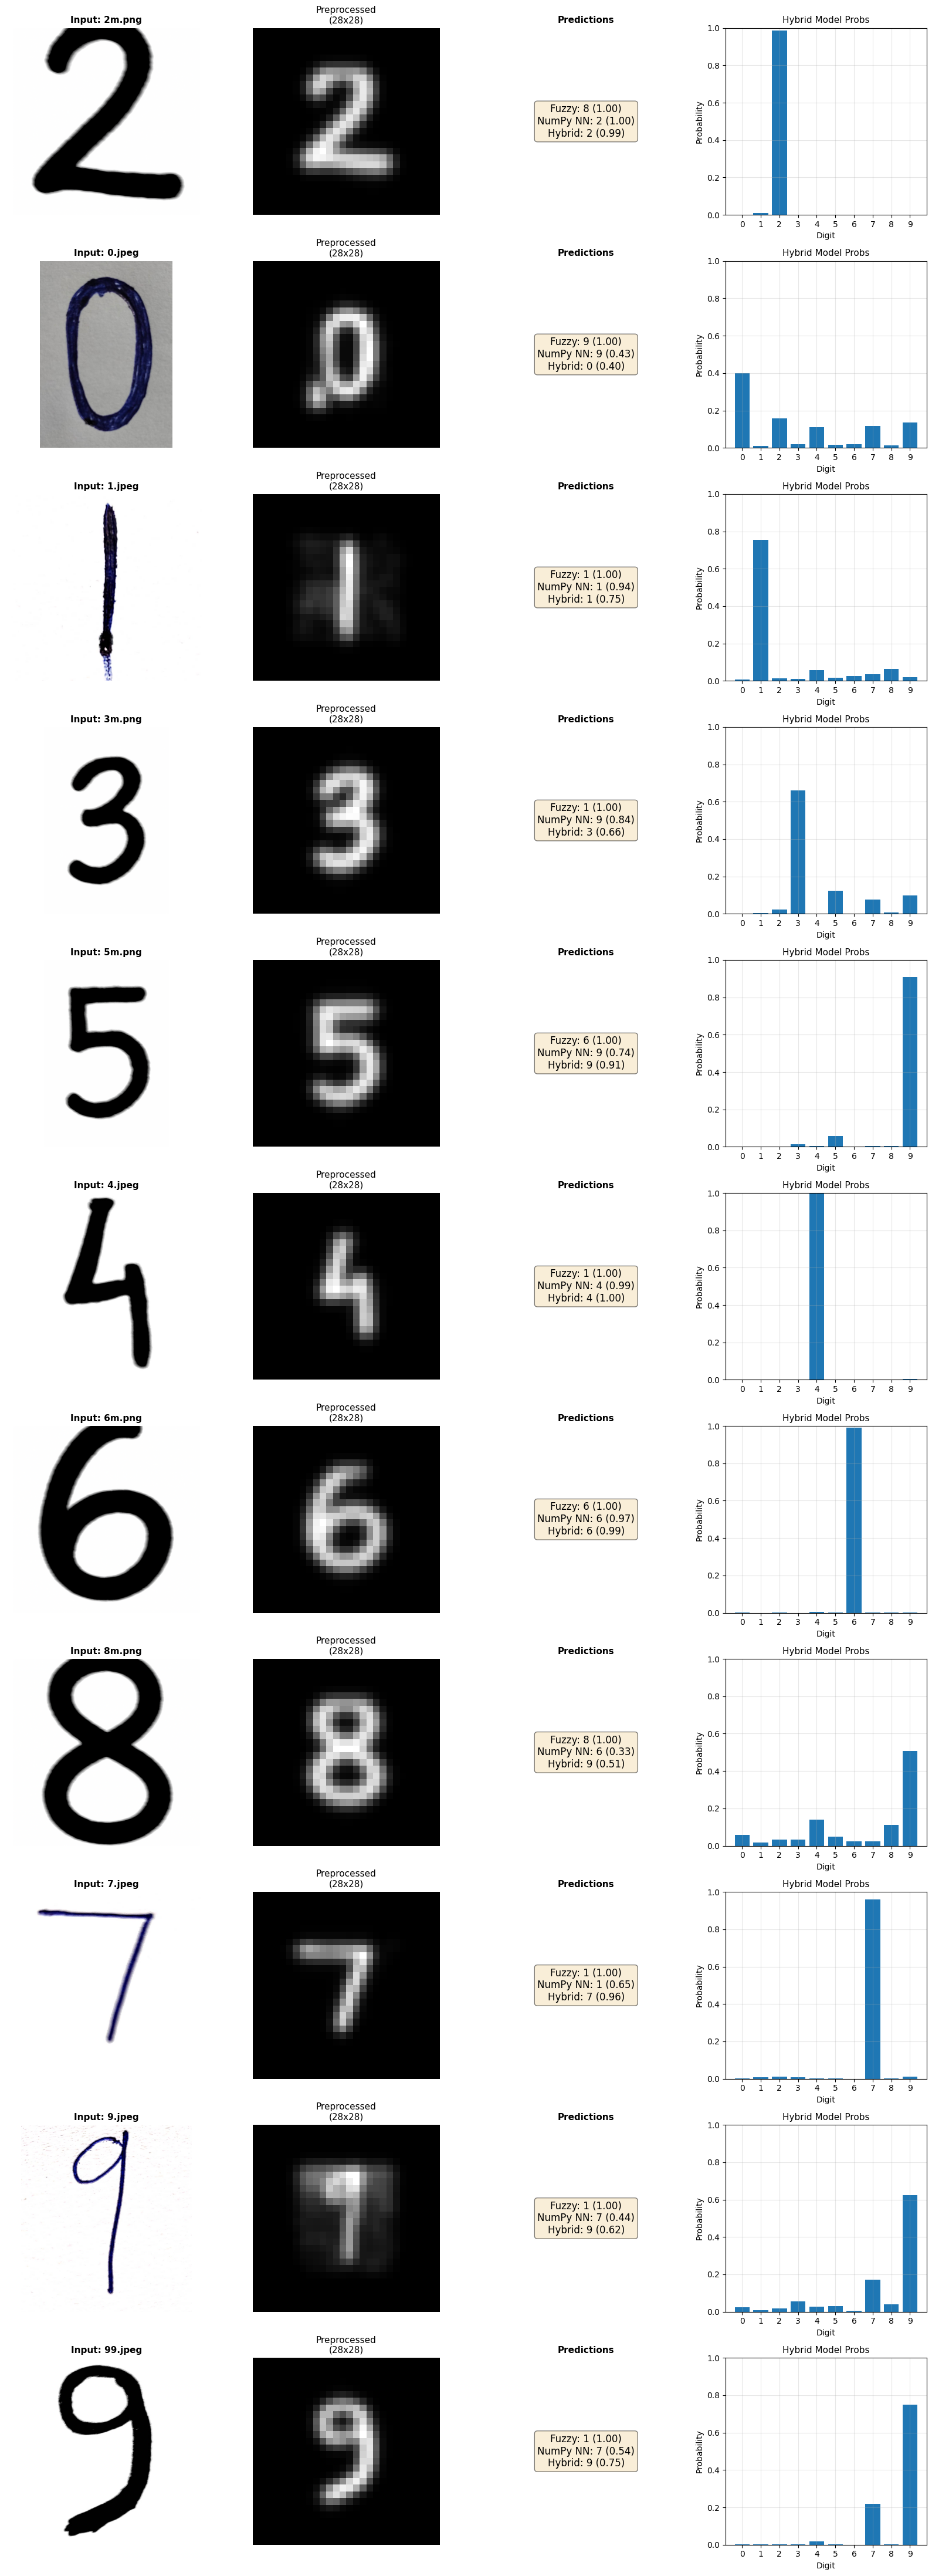


ALL MODELS TRAINED AND READY!


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from PIL import Image
import os
from scipy import ndimage

# Set seeds
np.random.seed(42)
tf.random.set_seed(42)

print("="*70)
print("COMPLETE NEURO-FUZZY HYBRID DIGIT RECOGNITION SYSTEM")
print("Training 3 Models: Neural Network, Fuzzy, and Neuro-Fuzzy Hybrid")
print("="*70)

# ============================================================================
# FUZZY CLASSIFIER IMPLEMENTATION
# ============================================================================

class FuzzyGaussianClassifier:
    """Simple Gaussian fuzzy classifier using class statistics"""

    def __init__(self):
        self.mu = None
        self.sigma = None
        self.K = None
        self.eps = 1e-8

    def fit(self, X_train, y_train):
        """Compute class means and standard deviations"""
        classes = np.unique(y_train)
        self.K = len(classes)
        D = X_train.shape[1]

        self.mu = np.zeros((self.K, D), dtype=np.float64)
        self.sigma = np.zeros((self.K, D), dtype=np.float64)

        for k in classes:
            Xk = X_train[y_train == k]
            if Xk.shape[0] > 0:
                self.mu[k] = Xk.mean(axis=0)
                self.sigma[k] = Xk.std(axis=0) + 1e-3
            else:
                self.mu[k] = np.zeros(D)
                self.sigma[k] = np.ones(D)

    def predict_proba(self, X):
        """Predict probabilities using Gaussian membership functions"""
        N = X.shape[0]
        logm = np.zeros((N, self.K), dtype=np.float64)

        for k in range(self.K):
            diff = (X - self.mu[k]) / (self.sigma[k] + self.eps)
            log_phi = -0.5 * (diff ** 2) - np.log(self.sigma[k] + self.eps)
            logm[:, k] = log_phi.sum(axis=1)

        # Stable softmax
        logm_max = logm.max(axis=1, keepdims=True)
        expm = np.exp(logm - logm_max)
        probs = expm / expm.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)

# ============================================================================
# NUMPY NEURAL NETWORK IMPLEMENTATION
# ============================================================================

class NumpyMLP:
    """Custom NumPy MLP: 64 -> 128 -> 64 -> 10"""

    def __init__(self, layer_sizes, lr=0.01, weight_decay=1e-4):
        self.sizes = layer_sizes
        self.lr = lr
        self.weight_decay = weight_decay
        self.params = {}

        # Xavier initialization
        for i in range(len(layer_sizes)-1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i+1]
            limit = np.sqrt(6.0 / (in_dim + out_dim))
            W = np.random.uniform(-limit, limit, size=(in_dim, out_dim)).astype(np.float32)
            b = np.zeros((1, out_dim), dtype=np.float32)
            self.params[f"W{i}"] = W
            self.params[f"b{i}"] = b

    def relu(self, x):
        return np.maximum(0, x)

    def relu_grad(self, x):
        return (x > 0).astype(x.dtype)

    def softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        ez = np.exp(z)
        return ez / np.sum(ez, axis=1, keepdims=True)

    def forward(self, X):
        caches = {}
        A = X
        caches["A0"] = A
        L = len(self.sizes) - 1

        # Hidden layers
        for i in range(L-1):
            Z = A.dot(self.params[f"W{i}"]) + self.params[f"b{i}"]
            A = self.relu(Z)
            caches[f"Z{i+1}"] = Z
            caches[f"A{i+1}"] = A

        # Output layer
        i_out = L-1
        Z_out = A.dot(self.params[f"W{i_out}"]) + self.params[f"b{i_out}"]
        caches[f"Z{L}"] = Z_out
        probs = self.softmax(Z_out)
        caches["probs"] = probs
        return probs, caches

    def backward(self, caches, Y_true):
        grads = {}
        L = len(self.sizes) - 1
        probs = caches["probs"]
        N = Y_true.shape[0]

        dZ = (probs - Y_true) / N
        A_prev = caches[f"A{L-1}"] if L-1 >= 0 else caches["A0"]
        grads[f"dW{L-1}"] = A_prev.T.dot(dZ) + self.weight_decay * self.params[f"W{L-1}"]
        grads[f"db{L-1}"] = np.sum(dZ, axis=0, keepdims=True)

        dA_prev = dZ.dot(self.params[f"W{L-1}"].T)
        for i in reversed(range(L-1)):
            Z = caches[f"Z{i+1}"]
            dZ = dA_prev * self.relu_grad(Z)
            A_prev = caches[f"A{i}"]
            grads[f"dW{i}"] = A_prev.T.dot(dZ) + self.weight_decay * self.params[f"W{i}"]
            grads[f"db{i}"] = np.sum(dZ, axis=0, keepdims=True)
            if i > 0:
                dA_prev = dZ.dot(self.params[f"W{i}"].T)
        return grads

    def step(self, grads):
        L = len(self.sizes) - 1
        for i in range(L):
            self.params[f"W{i}"] -= self.lr * grads[f"dW{i}"]
            self.params[f"b{i}"] -= self.lr * grads[f"db{i}"]

    def predict(self, X):
        probs, _ = self.forward(X)
        return np.argmax(probs, axis=1)

    def predict_proba(self, X):
        probs, _ = self.forward(X)
        return probs

# ============================================================================
# TENSORFLOW NEURO-FUZZY HYBRID MODEL
# ============================================================================

class FuzzyLayer(keras.layers.Layer):
    """Custom Fuzzy Layer with Gaussian membership functions"""

    def __init__(self, num_rules=5, **kwargs):
        super(FuzzyLayer, self).__init__(**kwargs)
        self.num_rules = num_rules

    def build(self, input_shape):
        self.centers = self.add_weight(
            name='centers',
            shape=(input_shape[-1], self.num_rules),
            initializer=keras.initializers.RandomUniform(0.2, 0.8),
            trainable=True
        )
        self.widths = self.add_weight(
            name='widths',
            shape=(input_shape[-1], self.num_rules),
            initializer=keras.initializers.Constant(0.3),
            trainable=True
        )
        super(FuzzyLayer, self).build(input_shape)

    def call(self, inputs):
        inputs_expanded = tf.expand_dims(inputs, -1)
        memberships = tf.exp(
            -tf.square(inputs_expanded - self.centers) /
            (2 * tf.square(tf.abs(self.widths) + 1e-6))
        )
        rule_activations = tf.reduce_prod(memberships, axis=1)
        return rule_activations

    def get_config(self):
        config = super(FuzzyLayer, self).get_config()
        config.update({'num_rules': self.num_rules})
        return config


class FuzzyInferenceLayer(keras.layers.Layer):
    """Fuzzy Inference Layer (Takagi-Sugeno style)"""

    def __init__(self, num_classes, **kwargs):
        super(FuzzyInferenceLayer, self).__init__(**kwargs)
        self.num_classes = num_classes

    def build(self, input_shape):
        num_rules = input_shape[-1]
        self.consequents = self.add_weight(
            name='consequents',
            shape=(num_rules, self.num_classes),
            initializer=keras.initializers.GlorotUniform(),
            trainable=True
        )
        super(FuzzyInferenceLayer, self).build(input_shape)

    def call(self, inputs):
        normalized = inputs / (tf.reduce_sum(inputs, axis=-1, keepdims=True) + 1e-6)
        output = tf.matmul(normalized, self.consequents)
        return output

    def get_config(self):
        config = super(FuzzyInferenceLayer, self).get_config()
        config.update({'num_classes': self.num_classes})
        return config

# ============================================================================
# LOAD AND PREPARE DATA (SAME SPLIT FOR ALL MODELS)
# ============================================================================

print("\n[STEP 1] Loading MNIST data with unified train/val/test split...")
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Split: 60/20/20 (train/val/test from full training set)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42
)

print(f"Training: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

# Prepare flattened data for Fuzzy and NumPy models
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

# Standardize for Fuzzy and NumPy models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_val_scaled = scaler.transform(X_val_flat)
X_test_scaled = scaler.transform(X_test_flat)

# ============================================================================
# TRAIN MODEL 1: FUZZY GAUSSIAN CLASSIFIER
# ============================================================================

print("\n" + "="*70)
print("MODEL 1: FUZZY GAUSSIAN CLASSIFIER")
print("="*70)

fuzzy_model = FuzzyGaussianClassifier()
fuzzy_model.fit(X_train_scaled, y_train)

fuzzy_val_pred = fuzzy_model.predict(X_val_scaled)
fuzzy_val_acc = accuracy_score(y_val, fuzzy_val_pred)

fuzzy_test_pred = fuzzy_model.predict(X_test_scaled)
fuzzy_test_acc = accuracy_score(y_test, fuzzy_test_pred)

print(f"\nValidation Accuracy: {fuzzy_val_acc:.4f}")
print(f"Test Accuracy:       {fuzzy_test_acc:.4f}")

# ============================================================================
# TRAIN MODEL 2: NUMPY NEURAL NETWORK
# ============================================================================

print("\n" + "="*70)
print("MODEL 2: NUMPY NEURAL NETWORK (64->128->64->10)")
print("="*70)

def one_hot(y, K):
    Y = np.zeros((y.shape[0], K), dtype=np.float32)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

K = 10
numpy_model = NumpyMLP([784, 128, 64, K], lr=0.01, weight_decay=1e-4)
epochs = 50
batch_size = 64

Y_train_oh = one_hot(y_train, K)
n_train = X_train_scaled.shape[0]

print("\nTraining...")
for ep in range(1, epochs+1):
    perm = np.random.permutation(n_train)
    Xsh = X_train_scaled[perm]
    Ysh = Y_train_oh[perm]

    for i in range(0, n_train, batch_size):
        xb = Xsh[i:i+batch_size]
        yb = Ysh[i:i+batch_size]
        probs, caches = numpy_model.forward(xb)
        grads = numpy_model.backward(caches, yb)
        numpy_model.step(grads)

    if ep % 10 == 0 or ep == epochs:
        val_pred = numpy_model.predict(X_val_scaled)
        val_acc = accuracy_score(y_val, val_pred)
        print(f"  Epoch {ep:02d}/{epochs} - Val Accuracy: {val_acc:.4f}")

numpy_val_pred = numpy_model.predict(X_val_scaled)
numpy_val_acc = accuracy_score(y_val, numpy_val_pred)

numpy_test_pred = numpy_model.predict(X_test_scaled)
numpy_test_acc = accuracy_score(y_test, numpy_test_pred)

print(f"\nValidation Accuracy: {numpy_val_acc:.4f}")
print(f"Test Accuracy:       {numpy_test_acc:.4f}")

# ============================================================================
# TRAIN MODEL 3: NEURO-FUZZY HYBRID (TENSORFLOW)
# ============================================================================

print("\n" + "="*70)
print("MODEL 3: NEURO-FUZZY HYBRID (TENSORFLOW)")
print("="*70)

# Build Neuro-Fuzzy model
inputs = keras.Input(shape=(28, 28))
x = keras.layers.Flatten()(inputs)

# Neural feature extraction
x = keras.layers.Dense(128, activation='relu', name='feature_1')(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(64, activation='relu', name='feature_2')(x)
x = keras.layers.Dropout(0.3)(x)

# Fuzzy processing
fuzzy_features = keras.layers.Dense(32, activation='sigmoid', name='fuzzy_input')(x)
fuzzy_rules = FuzzyLayer(num_rules=20, name='fuzzy_rules')(fuzzy_features)
fuzzy_output = FuzzyInferenceLayer(num_classes=10, name='fuzzy_inference')(fuzzy_rules)

# Neural path
neural_output = keras.layers.Dense(10, activation='linear', name='neural_output')(x)

# Hybrid combination
combined = keras.layers.Add(name='hybrid_combination')([fuzzy_output, neural_output])
outputs = keras.layers.Activation('softmax', name='final_output')(combined)

hybrid_model = keras.Model(inputs=inputs, outputs=outputs, name='NeuroFuzzy_Hybrid')

hybrid_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nTraining...")
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

history = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop],
    verbose=0
)

# Show progress
for ep in range(0, len(history.history['accuracy']), 2):
    print(f"  Epoch {ep+1:02d}/20 - Val Accuracy: {history.history['val_accuracy'][ep]:.4f}")

hybrid_val_loss, hybrid_val_acc = hybrid_model.evaluate(X_val, y_val, verbose=0)
hybrid_test_loss, hybrid_test_acc = hybrid_model.evaluate(X_test, y_test, verbose=0)

print(f"\nValidation Accuracy: {hybrid_val_acc:.4f}")
print(f"Test Accuracy:       {hybrid_test_acc:.4f}")

# ============================================================================
# COMPARISON SUMMARY
# ============================================================================

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)
print(f"{'Model':<30} {'Val Accuracy':<15} {'Test Accuracy':<15}")
print("-"*70)
print(f"{'1. Fuzzy Gaussian':<30} {fuzzy_val_acc:.4f}{'':11} {fuzzy_test_acc:.4f}")
print(f"{'2. NumPy Neural Network':<30} {numpy_val_acc:.4f}{'':11} {numpy_test_acc:.4f}")
print(f"{'3. Neuro-Fuzzy Hybrid':<30} {hybrid_val_acc:.4f}{'':11} {hybrid_test_acc:.4f}")
print("="*70)

# ============================================================================
# ENHANCED IMAGE PREPROCESSING FOR CUSTOM IMAGES
# ============================================================================

def preprocess_custom_image(image_path, show_steps=False):
    """
    Optimized preprocessing for thin-stroked blue digits on white/gray paper
    Preserves original stroke width, focuses on proper centering and contrast
    """
    try:
        from scipy.ndimage import binary_closing, binary_opening

        # Load image
        img = Image.open(image_path)
        original = np.array(img)

        # Convert to grayscale
        if len(original.shape) == 3:
            img_gray = np.array(img.convert('L'))
        else:
            img_gray = original.copy()

        # Invert so digit is WHITE on BLACK background (like MNIST)
        img_gray = 255 - img_gray

        # Use percentile-based threshold to isolate digit from background
        # For thin blue strokes, use less aggressive threshold
        threshold = np.percentile(img_gray, 70)  # Keep top 30% intensity
        binary = (img_gray > threshold).astype(np.uint8) * 255

        # Light cleanup - preserve thin strokes
        binary = binary_opening(binary > 0, structure=np.ones((2, 2))).astype(np.uint8) * 255
        binary = binary_closing(binary > 0, structure=np.ones((2, 2))).astype(np.uint8) * 255

        # Find digit bounding box
        coords = np.column_stack(np.where(binary > 0))
        if len(coords) == 0:
            # Try lower threshold
            threshold = np.percentile(img_gray, 60)
            binary = (img_gray > threshold).astype(np.uint8) * 255
            coords = np.column_stack(np.where(binary > 0))
            if len(coords) == 0:
                return None, False

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        # Add moderate padding
        h_orig, w_orig = binary.shape
        pad = 15
        y_min = max(0, y_min - pad)
        y_max = min(h_orig, y_max + pad)
        x_min = max(0, x_min - pad)
        x_max = min(w_orig, x_max + pad)

        cropped = binary[y_min:y_max, x_min:x_max]

        # Make square with MNIST-like padding
        h, w = cropped.shape
        size = int(max(h, w) * 1.3)

        square = np.zeros((size, size), dtype=np.uint8)
        y_offset = (size - h) // 2
        x_offset = (size - w) // 2
        square[y_offset:y_offset+h, x_offset:x_offset+w] = cropped

        # Resize to 20x20 (MNIST standard)
        img_pil = Image.fromarray(square)
        img_20 = np.array(img_pil.resize((20, 20), Image.LANCZOS))

        # Place in 28x28 with standard 4-pixel border
        img_28 = np.zeros((28, 28), dtype=np.float32)
        img_28[4:24, 4:24] = img_20

        # Apply Gaussian blur to smooth edges (MNIST style)
        img_28 = ndimage.gaussian_filter(img_28, sigma=0.8)

        # Normalize to [0, 1]
        if img_28.max() > 0:
            img_28 = img_28 / 255.0

        final_array = np.expand_dims(img_28, axis=0)

        if show_steps:
            fig, axes = plt.subplots(3, 3, figsize=(15, 15))

            axes[0, 0].imshow(original, cmap='gray')
            axes[0, 0].set_title('1. Original Input', fontsize=12, fontweight='bold')
            axes[0, 0].axis('off')

            axes[0, 1].imshow(img_gray, cmap='gray')
            axes[0, 1].set_title('2. Inverted', fontsize=12)
            axes[0, 1].axis('off')

            axes[0, 2].imshow(binary, cmap='gray')
            axes[0, 2].set_title(f'3. Binary (thresh={threshold:.0f})', fontsize=12)
            axes[0, 2].axis('off')

            axes[1, 0].imshow(cropped, cmap='gray')
            axes[1, 0].set_title('4. Cropped', fontsize=12)
            axes[1, 0].axis('off')

            axes[1, 1].imshow(square, cmap='gray')
            axes[1, 1].set_title('5. Centered & Squared', fontsize=12)
            axes[1, 1].axis('off')

            axes[1, 2].imshow(img_28, cmap='gray')
            axes[1, 2].set_title('6. Final 28x28', fontsize=12, fontweight='bold')
            axes[1, 2].axis('off')

            # Show 3 real MNIST examples
            axes[2, 0].imshow(X_test[0], cmap='gray')
            axes[2, 0].set_title(f'MNIST: {y_test[0]}', fontsize=12)
            axes[2, 0].axis('off')

            axes[2, 1].imshow(X_test[1], cmap='gray')
            axes[2, 1].set_title(f'MNIST: {y_test[1]}', fontsize=12)
            axes[2, 1].axis('off')

            axes[2, 2].imshow(X_test[2], cmap='gray')
            axes[2, 2].set_title(f'MNIST: {y_test[2]}', fontsize=12)
            axes[2, 2].axis('off')

            plt.tight_layout()
            plt.show()

        return final_array, True

    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        import traceback
        traceback.print_exc()
        return None, False

# ============================================================================
# TEST ON CUSTOM IMAGES WITH ALL 3 MODELS
# ============================================================================

print("\n[TESTING CUSTOM IMAGES]")

image_paths = ["2m.png","0.jpeg","1.jpeg","3m.png","5m.png","4.jpeg","6m.png","8m.png","7.jpeg","9.jpeg","99.jpeg"]
existing_images = [p for p in image_paths if os.path.exists(p)]

if len(existing_images) == 0:
    print("\nNo custom images found. Place images in current directory.")
else:
    print(f"\nFound {len(existing_images)} image(s)\n")

    results_list = []

    for img_path in existing_images:
        img_array, success = preprocess_custom_image(img_path, show_steps=False)

        if success:
            # Hybrid model (TensorFlow)
            hybrid_pred = hybrid_model.predict(img_array, verbose=0)
            hybrid_class = np.argmax(hybrid_pred[0])
            hybrid_conf = hybrid_pred[0][hybrid_class]

            # Fuzzy model
            img_flat = scaler.transform(img_array.reshape(1, -1))
            fuzzy_probs = fuzzy_model.predict_proba(img_flat)
            fuzzy_class = np.argmax(fuzzy_probs[0])
            fuzzy_conf = fuzzy_probs[0][fuzzy_class]

            # NumPy NN model
            numpy_probs = numpy_model.predict_proba(img_flat)
            numpy_class = np.argmax(numpy_probs[0])
            numpy_conf = numpy_probs[0][numpy_class]

            results_list.append({
                'path': img_path,
                'image': img_array[0],
                'fuzzy': fuzzy_class,
                'fuzzy_conf': fuzzy_conf,
                'numpy': numpy_class,
                'numpy_conf': numpy_conf,
                'hybrid': hybrid_class,
                'hybrid_conf': hybrid_conf
            })

            print(f"{os.path.basename(img_path):15s}")
            print(f"  Fuzzy:        {fuzzy_class} (conf: {fuzzy_conf:.3f})")
            print(f"  NumPy NN:     {numpy_class} (conf: {numpy_conf:.3f})")
            print(f"  Neuro-Fuzzy:  {hybrid_class} (conf: {hybrid_conf:.3f})")
            print()

    # Visualize all results with input images
    if len(results_list) > 0:
        print(f"\n{'='*70}")
        print("VISUALIZATION OF ALL PREDICTIONS")
        print('='*70)

        n_images = len(results_list)
        fig, axes = plt.subplots(n_images, 4, figsize=(16, 4*n_images))

        if n_images == 1:
            axes = axes.reshape(1, -1)

        for i, result in enumerate(results_list):
            # Load and show original input image
            original_img = Image.open(result['path'])
            axes[i, 0].imshow(original_img, cmap='gray')
            axes[i, 0].set_title(f"Input: {os.path.basename(result['path'])}",
                                fontsize=11, fontweight='bold')
            axes[i, 0].axis('off')

            # Show preprocessed image
            axes[i, 1].imshow(result['image'], cmap='gray')
            axes[i, 1].set_title(f"Preprocessed\n(28x28)", fontsize=11)
            axes[i, 1].axis('off')

            # Show all 3 predictions
            pred_text = (f"Fuzzy: {result['fuzzy']} ({result['fuzzy_conf']:.2f})\n"
                        f"NumPy NN: {result['numpy']} ({result['numpy_conf']:.2f})\n"
                        f"Hybrid: {result['hybrid']} ({result['hybrid_conf']:.2f})")

            axes[i, 2].text(0.5, 0.5, pred_text,
                           ha='center', va='center', fontsize=12,
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
            axes[i, 2].set_title("Predictions", fontsize=11, fontweight='bold')
            axes[i, 2].axis('off')

            # Show probability bar chart for hybrid model
            axes[i, 3].bar(range(10), hybrid_model.predict(result['image'].reshape(1, 28, 28), verbose=0)[0])
            axes[i, 3].set_xlabel('Digit', fontsize=10)
            axes[i, 3].set_ylabel('Probability', fontsize=10)
            axes[i, 3].set_title('Hybrid Model Probs', fontsize=11)
            axes[i, 3].set_xticks(range(10))
            axes[i, 3].grid(True, alpha=0.3)
            axes[i, 3].set_ylim([0, 1])

        plt.tight_layout()
        plt.show()

print("\n" + "="*70)
print("ALL MODELS TRAINED AND READY!")
print("="*70)

# ============================================================================
# UTILITY FUNCTION
# ============================================================================

def predict_digit_all_models(image_path, show_details=True):
    """Predict using all 3 models"""
    img_array, success = preprocess_custom_image(image_path, show_steps=show_details)

    if not success:
        return None

    # Hybrid
    hybrid_pred = hybrid_model.predict(img_array, verbose=0)
    hybrid_class = np.argmax(hybrid_pred[0])

    # Fuzzy
    img_flat = scaler.transform(img_array.reshape(1, -1))
    fuzzy_probs = fuzzy_model.predict_proba(img_flat)
    fuzzy_class = np.argmax(fuzzy_probs[0])

    # NumPy NN
    numpy_probs = numpy_model.predict_proba(img_flat)
    numpy_class = np.argmax(numpy_probs[0])

    if show_details:
        print(f"\n{'='*50}")
        print(f"Image: {image_path}")
        print(f"{'='*50}")
        print(f"Fuzzy Gaussian:      {fuzzy_class}")
        print(f"NumPy Neural Net:    {numpy_class}")
        print(f"Neuro-Fuzzy Hybrid:  {hybrid_class}")

    return {'fuzzy': fuzzy_class, 'numpy_nn': numpy_class, 'hybrid': hybrid_class}
